In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration affichage
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Chargement des données
df = pd.read_csv('../data/creditcard.csv')

print(f"Shape du dataset : {df.shape}")
df.head()

Shape du dataset : (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Informations générales
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [3]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum().sum())  # Total des valeurs manquantes

Valeurs manquantes par colonne :
0


In [6]:
# Distribution de la target
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("Répartition des classes :")
print(f"Normal (0) : {class_counts[0]} transactions ({class_pct[0]:.3f}%)")
print(f"Fraude (1) : {class_counts[1]} transactions ({class_pct[1]:.3f}%)")

Répartition des classes :
Normal (0) : 284315 transactions (99.827%)
Fraude (1) : 492 transactions (0.173%)


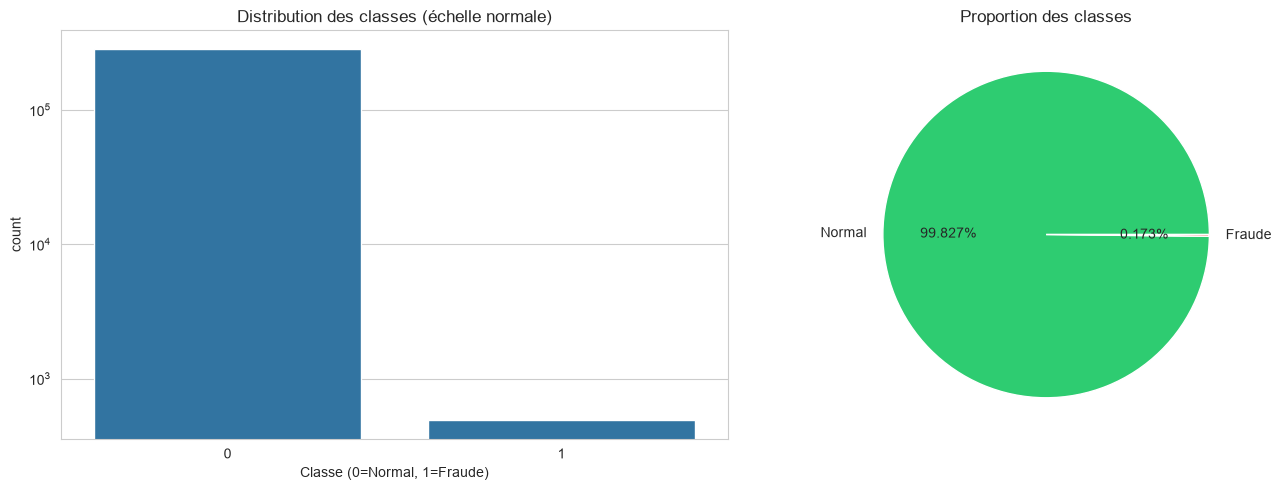

In [7]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres (échelle log pour voir les deux classes)
sns.countplot(data=df, x='Class', ax=axes[0])
axes[0].set_title('Distribution des classes (échelle normale)')
axes[0].set_yscale('log')
axes[0].set_xlabel('Classe (0=Normal, 1=Fraude)')

# Graphique en camembert
axes[1].pie(class_counts, labels=['Normal', 'Fraude'], autopct='%1.3f%%', 
            colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Proportion des classes')

plt.tight_layout()
plt.show()

In [8]:
# Statistiques descriptives de Amount par classe
print("Statistiques 'Amount' par classe :")
print(df.groupby('Class')['Amount'].describe())

Statistiques 'Amount' par classe :
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


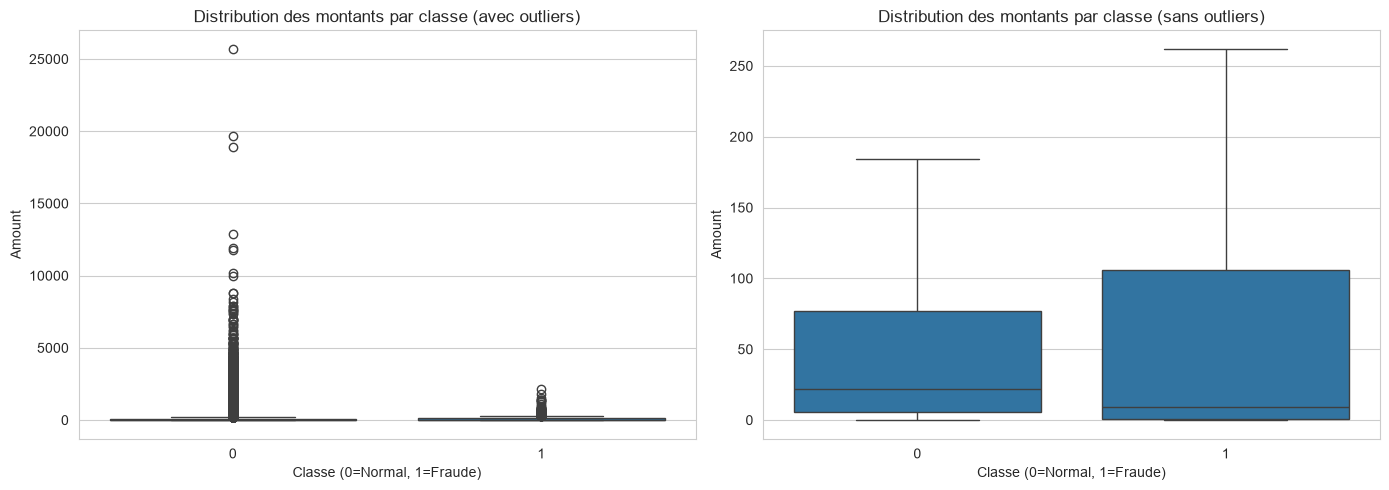

In [9]:
# Visualisation des distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution complète (avec outliers)
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0])
axes[0].set_title('Distribution des montants par classe (avec outliers)')
axes[0].set_xlabel('Classe (0=Normal, 1=Fraude)')

# Distribution zoomée (sans les extrêmes, pour mieux voir)
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[1], showfliers=False)
axes[1].set_title('Distribution des montants par classe (sans outliers)')
axes[1].set_xlabel('Classe (0=Normal, 1=Fraude)')

plt.tight_layout()
plt.show()

La moyenne des fraudes est plus élevée (122€ vs 88€), mais la médiane des fraudes est plus basse (9.25€ vs 22€). La distribution est asymétrique et influencée par les extrêmes. Le boxplot (bleu) le confirme car la boîte des fraudes est plus étalée et plus haute en Q3 (106€ vs 77€), ce qui tire la moyenne vers le haut mais une bonne partie des fraudes sont en réalité de très petits montants (médiane à 9.25€, bien en dessous des 22€ du normal).

Les fraudeurs testent donc souvent de petits montants (pour vérifier qu'une carte volée fonctionne, ou rester sous des seuils de détection), mais quand la fraude "réussit" à plus grande échelle, certains montants peuvent grimper plus haut proportionnellement que les transactions normales légitimes.

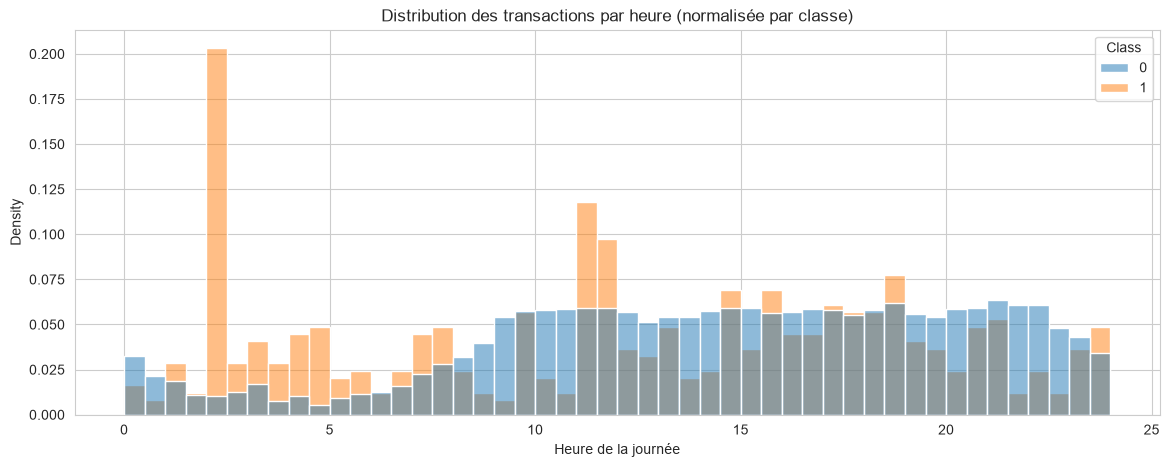

In [10]:
# Time est en secondes depuis la première transaction, on  convertit en heures
df['Hour'] = (df['Time'] / 3600) % 24

fig, ax = plt.subplots(figsize=(14, 5))
sns.histplot(data=df, x='Hour', hue='Class', bins=48, stat='density', 
             common_norm=False, alpha=0.5)
ax.set_title('Distribution des transactions par heure (normalisée par classe)')
ax.set_xlabel('Heure de la journée')
plt.show()

Pendant les heures normales d'activité (9h–22h environ), les distributions normale et fraude se ressemblent, les fraudeurs se "fondent" dans le trafic légitime, probablement de manière délibérée.
Mais on voir qu'autour de 2h–3h du matin, le pic de fraude (orange, ~0.20 de densité) est nettement supérieur au pic du trafic normal (~0.03) à la même heure. C'est-à-dire que proportionnellement, beaucoup plus de fraudes se produisent à 2-3h du matin qu'à n'importe quelle autre heure alors que le trafic légitime, lui, est à son minimum à cette heure (logique, tout le monde dort).

On peut conclure que les transactions nocturnes sont disproportionnellement plus risquées.

In [11]:
## Comme les features V1 à V28 sont déjà transformées par PCA (anonymisées par la banque pour confidentialité), on ne peut pas interpréter leur sens métier mais on peut identifier lesquelles séparent le mieux les deux classes.

# Calcul de la différence de moyenne absolue entre fraude et normal pour chaque feature V
v_features = [col for col in df.columns if col.startswith('V')]

mean_diff = df.groupby('Class')[v_features].mean()
diff_abs = (mean_diff.loc[1] - mean_diff.loc[0]).abs().sort_values(ascending=False)

print("Top 10 features V les plus discriminantes (différence de moyenne) :")
print(diff_abs.head(10))

Top 10 features V les plus discriminantes (différence de moyenne) :
V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749
dtype: float64


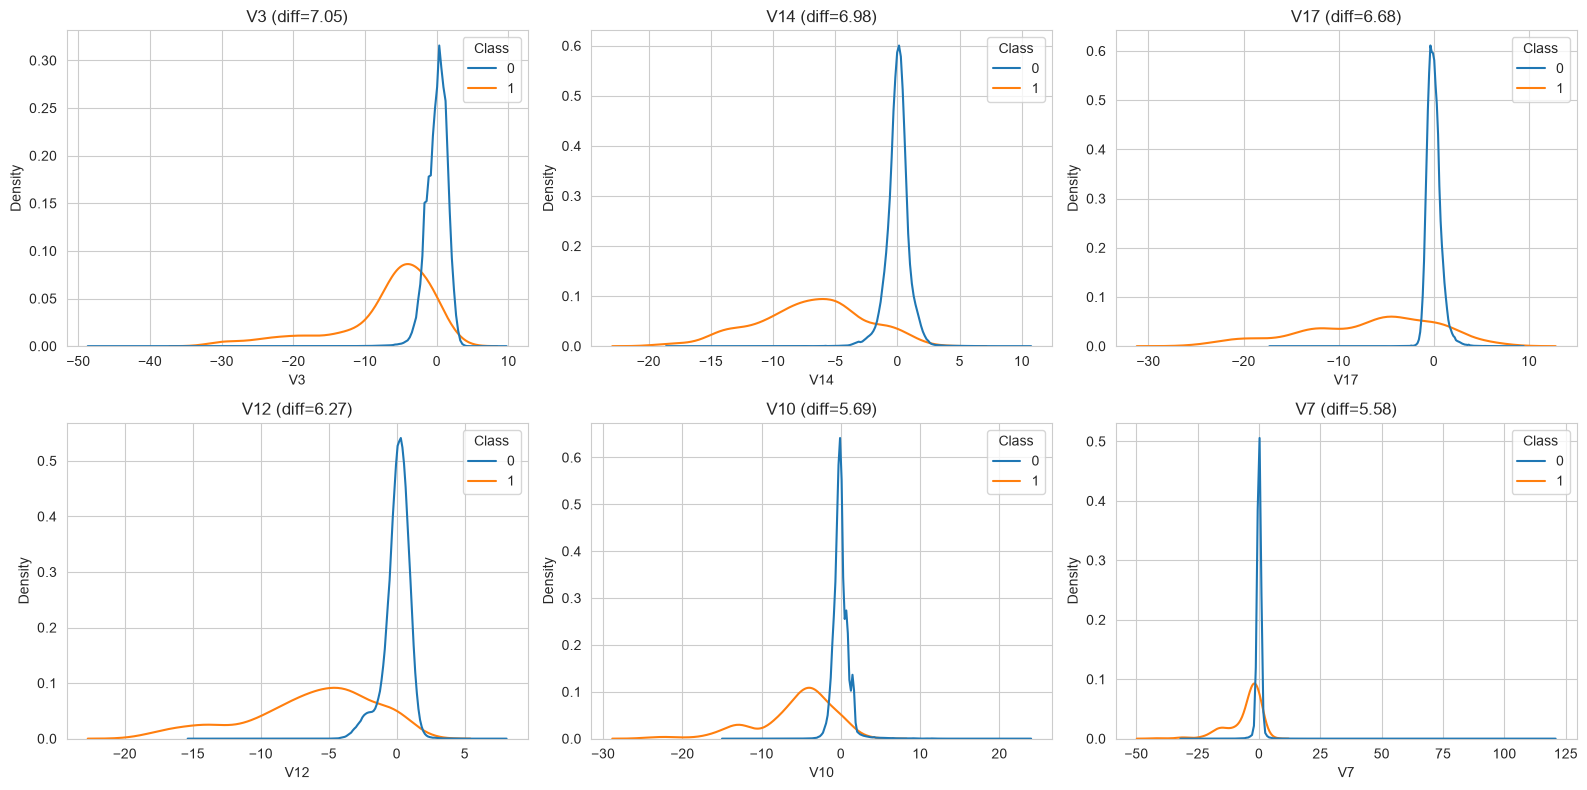

In [12]:
# Visualisation des 6 features les plus discriminantes
top_features = diff_abs.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.kdeplot(data=df, x=feature, hue='Class', ax=axes[i], common_norm=False)
    axes[i].set_title(f'{feature} (diff={diff_abs[feature]:.2f})')

plt.tight_layout()
plt.show()

Le graphique montre une différence de moyenne clair entre les classes (normal et fraude) pour les 6 features. C'est intéressant mais pas assez rigoureuse statistiquement.

Pour la suite, je part sur le test de Mann-Whitney U billatéral (non paramétrique) vu l'assymétrie des données et une corrélation point-bisériale afin d'avoir une magnitude d'effet standardisée pour complèter la p-value qui ne dit rien sur l'ampleur de la différence. J'ai préféré le billatéral car je ne sais pas a priori si la fraude pousse les valeurs vers le haut ou le bas.

In [13]:
from scipy import stats

results = []

for feature in v_features:
    fraud_vals = df[df['Class'] == 1][feature]
    normal_vals = df[df['Class'] == 0][feature]
    
    # Mann-Whitney U test (non-paramétrique, robuste à la non-normalité)
    u_stat, p_value = stats.mannwhitneyu(fraud_vals, normal_vals, alternative='two-sided')
    
    # Corrélation point-bisériale
    corr, _ = stats.pointbiserialr(df['Class'], df[feature])
    
    results.append({
        'feature': feature,
        'p_value': p_value,
        'point_biserial_corr': corr,
        'abs_corr': abs(corr)
    })

results_df = pd.DataFrame(results).sort_values('abs_corr', ascending=False)
print("Top 10 features par corrélation point-bisériale (avec p-value) :")
print(results_df.head(10).to_string(index=False))

Top 10 features par corrélation point-bisériale (avec p-value) :
feature       p_value  point_biserial_corr  abs_corr
    V17 9.219384e-124            -0.326481  0.326481
    V14 1.471581e-260            -0.302544  0.302544
    V12 8.416027e-247            -0.260593  0.260593
    V10 9.611131e-222            -0.216883  0.216883
    V16 1.808172e-156            -0.196539  0.196539
     V3 1.211048e-219            -0.192961  0.192961
     V7 1.464234e-146            -0.187257  0.187257
    V11 4.910592e-226             0.154876  0.154876
     V4 3.625904e-248             0.133447  0.133447
    V18  2.648962e-77            -0.111485  0.111485


In [14]:
# Vérification : toutes les features sont-elles statistiquement significatives ?
significant = results_df[results_df['p_value'] < 0.05]
print(f"\nFeatures statistiquement significatives (p < 0.05) : {len(significant)}/{len(v_features)}")


Features statistiquement significatives (p < 0.05) : 25/28


On voir que le classement change légèrement par rapport à la différence de moyenne brute, V17 passe en première position (corrélation -0.326) au lieu de V3, et V16 apparaît dans le top 10 alors qu'elle n'y était pas avant. 25 features sur 28 sont statistiquement significatives (p < 0.05).  Ce qui est prévisible vue les 284 807 observations, la significativité statistique est presque acquise même pour des effets très faibles (V18 : significative, mais corrélation de seulement 0.11, donc un effet réel mais modeste).

La vraie information utile pour la suite n'est donc pas "combien de features sont significatives", mais l'amplitude de la corrélation, c'est elle qui guidera le feature engineering et donnera un premier indice de l'importance attendue dans le modèle final.

In [15]:
# Détection des doublons exacts
n_duplicates = df.duplicated().sum()
print(f"Nombre de doublons exacts : {n_duplicates}")
print(f"Soit {n_duplicates/len(df)*100:.3f}% du dataset")

Nombre de doublons exacts : 1081
Soit 0.380% du dataset


In [16]:
# Suppression des doublons en gardant le premier
if n_duplicates > 0:
    df = df.drop_duplicates(keep='first')
    print(f"Dataset après suppression : {df.shape}")
else:
    print("Aucun doublon détecté, dataset inchangé")

Dataset après suppression : (283726, 32)


In [17]:
# Sauvegarde du dataset nettoyé
df.drop(columns=['Hour']).to_csv('../data/creditcard_cleaned.csv', index=False)
print(f"Dataset nettoyé sauvegardé : {df.shape[0]} lignes, {df.shape[1]-1} colonnes")
print("Colonne 'Hour' conservée en mémoire pour l'EDA, sera recréée en feature engineering")

Dataset nettoyé sauvegardé : 283726 lignes, 31 colonnes
Colonne 'Hour' conservée en mémoire pour l'EDA, sera recréée en feature engineering


## 📋 Synthèse EDA

### Dataset
- **284 807 transactions** sur 2 jours → **283 726 après suppression de 1 081 doublons (0.38%)**
- **0 valeur manquante**
- **31 features** : Time, Amount, V1-V28 (PCA anonymisées), Class

### Déséquilibre des classes
- Normal : 99.827% | Fraude : 0.173%
- Déséquilibre extrême 

### Insights clés
1. **Amount** : médiane fraude (9.25€) < médiane normal (22€), les fraudes ciblent souvent de petits montants
2. **Time** : pic de fraude marqué à **2h-3h du matin**, pattern temporel exploitable
3. **Top features discriminantes** (Mann-Whitney U + corrélation point-bisériale) :
   - Corrélation négative : V17 (-0.33), V14 (-0.30), V12 (-0.26), V10 (-0.22), V16 (-0.20)
   - Corrélation positive : V11 (+0.15), V4 (+0.13)
   - 25/28 features V statistiquement significatives

### Décisions pour la suite
- Créer des **features temporelles** (Hour, is_night) à partir de Time
- Créer des **features sur Amount** (log_amount, amount_normalized)
- Gérer le déséquilibre à l'étape modélisation (choix à faire : SMOTE vs class_weight vs autres)
- **Métrique principale** : F2-Score (pondère le Recall davantage que la Precision)